## ISE 5334 Homework 4  
#### Mason Lu


#### Note: AI tool (ChatGPT) was utilized to generate code.



In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier

from IPython.display import display

sns.set_theme(style="whitegrid")


In [2]:
BASE_DIR = "/Users/masonlu/Downloads/pointcloud_streamlit_app"
feasible_folder = os.path.join(BASE_DIR, "feasible")
infeasible_folder = os.path.join(BASE_DIR, "infeasible")

print("Feasible folder exists:", os.path.exists(feasible_folder))
print("Infeasible folder exists:", os.path.exists(infeasible_folder))
print("Base directory:", BASE_DIR)


Feasible folder exists: True
Infeasible folder exists: True
Base directory: /Users/masonlu/Downloads/pointcloud_streamlit_app


In [3]:
def read_ply(file_path):
    """
    Read an ASCII .ply file and return x, y, z coordinates only.
    """
    with open(file_path, "r") as f:
        lines = f.readlines()

    header_end = lines.index("end_header\n")
    pts = np.loadtxt(lines[header_end + 1:])

    return pts[:, :3]


def extract_features(points):
    """
    Extract simple geometric summary features from a point cloud.
    """
    x = points[:, 0]
    y = points[:, 1]
    z = points[:, 2]

    features = {
        "num_points": len(points),
        "centroid_x": np.mean(x),
        "centroid_y": np.mean(y),
        "centroid_z": np.mean(z),
        "x_range": np.max(x) - np.min(x),
        "y_range": np.max(y) - np.min(y),
        "z_range": np.max(z) - np.min(z),
        "var_x": np.var(x),
        "var_y": np.var(y),
        "var_z": np.var(z)
    }

    return features


def build_dataset(feasible_folder, infeasible_folder):
    rows = []

    if not os.path.exists(feasible_folder):
        raise FileNotFoundError(f"Feasible folder not found: {feasible_folder}")
    if not os.path.exists(infeasible_folder):
        raise FileNotFoundError(f"Infeasible folder not found: {infeasible_folder}")

    for fn in os.listdir(feasible_folder):
        if fn.lower().endswith(".ply"):
            pts = read_ply(os.path.join(feasible_folder, fn))
            feats = extract_features(pts)
            feats["label"] = 1
            feats["file"] = fn
            rows.append(feats)

    for fn in os.listdir(infeasible_folder):
        if fn.lower().endswith(".ply"):
            pts = read_ply(os.path.join(infeasible_folder, fn))
            feats = extract_features(pts)
            feats["label"] = 0
            feats["file"] = fn
            rows.append(feats)

    return pd.DataFrame(rows)


def plot_point_cloud(points, title="Point Cloud", sample_size=5000):
    """
    Plot a random subsample of a point cloud for visualization.
    """
    if len(points) > sample_size:
        idx = np.random.choice(len(points), sample_size, replace=False)
        points = points[idx]

    fig = plt.figure(figsize=(7, 6))
    ax = fig.add_subplot(111, projection="3d")
    ax.scatter(points[:, 0], points[:, 1], points[:, 2], s=1, alpha=0.6)
    ax.set_title(title)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    plt.show()


# Question 1  
Visualize the 3D point cloud data of a few designs and discuss what points should and should not be included in the analysis. Use dimension reduction and clustering to visualize the data and draw conclusions.




In [4]:
df = build_dataset(feasible_folder, infeasible_folder)

print("Dataset shape:", df.shape)
display(df.head())


Dataset shape: (500, 12)


,num_points,centroid_x,centroid_y,centroid_z,x_range,y_range,z_range,var_x,var_y,var_z,label,file
0,270081,-11.293553,6.856237,-508.994764,185.807809,175.708568,54.123235,2963.377689,2650.751017,40.864570,1,3890.stl_pointcloud.ply
1,273460,-11.422041,6.711312,-508.057959,185.807809,175.662821,271.784954,2930.336228,2619.140380,72.909069,1,4138.stl_pointcloud.ply
2,272369,-11.381141,6.579553,-507.565124,185.807809,175.668206,276.894440,2937.981500,2624.174259,93.998765,1,900.stl_pointcloud.ply
3,272729,-11.348682,6.650851,-507.731223,185.807809,175.664555,279.747935,2934.640913,2623.092829,85.698114,1,5336.stl_pointcloud.ply
4,273673,-11.463161,6.685667,-508.901016,185.807809,175.638091,269.352572,2930.928543,2614.850521,39.223487,1,4135.stl_pointcloud.ply


In [5]:
display(df.describe())
print("\nClass counts:")
display(df["label"].value_counts())


,num_points,centroid_x,centroid_y,centroid_z,x_range,y_range,z_range,var_x,var_y,var_z,label
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,269887.740000,-11.292350,6.714635,-508.218684,185.805374,175.675295,233.151357,2965.205626,2648.624517,70.438400,0.600000
std,5775.671299,0.239763,0.161828,0.785994,0.006176,0.020737,85.770422,60.236206,54.280624,25.640576,0.490389
min,248452.000000,-11.648185,6.515563,-510.439126,185.787143,175.622872,16.440270,2907.614216,2599.312052,0.032686,0.000000
25%,269553.500000,-11.399730,6.607912,-508.453620,185.807809,175.662821,269.529704,2935.651085,2621.976942,61.405078,0.000000
50%,271596.000000,-11.360968,6.666999,-508.020751,185.807809,175.664934,273.870884,2947.183861,2631.754050,76.563115,1.000000
75%,272740.500000,-11.290958,6.765462,-507.661149,185.807809,175.690063,276.593024,2967.496779,2649.720573,89.278807,1.000000
max,276370.000000,-10.224943,7.241004,-507.333623,185.809854,175.807140,301.081655,3191.019643,2850.698615,101.966402,1.000000



Class counts:


label
1    300
0    200
Name: count, dtype: int64

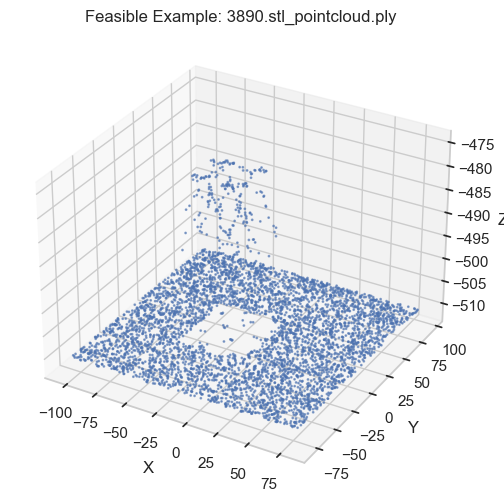

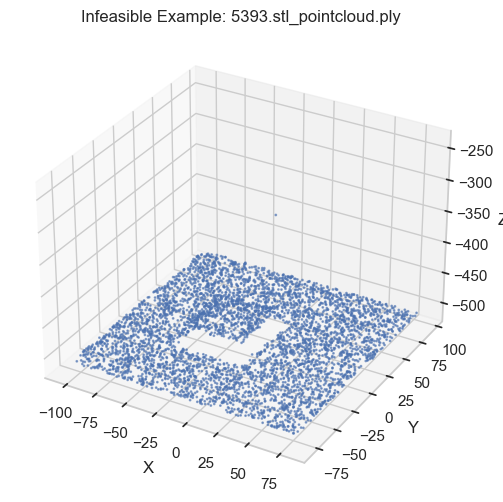

In [6]:
feasible_files = [f for f in os.listdir(feasible_folder) if f.lower().endswith(".ply")]
infeasible_files = [f for f in os.listdir(infeasible_folder) if f.lower().endswith(".ply")]

if feasible_files:
    pts_f = read_ply(os.path.join(feasible_folder, feasible_files[0]))
    plot_point_cloud(pts_f, title=f"Feasible Example: {feasible_files[0]}")

if infeasible_files:
    pts_i = read_ply(os.path.join(infeasible_folder, infeasible_files[0]))
    plot_point_cloud(pts_i, title=f"Infeasible Example: {infeasible_files[0]}")


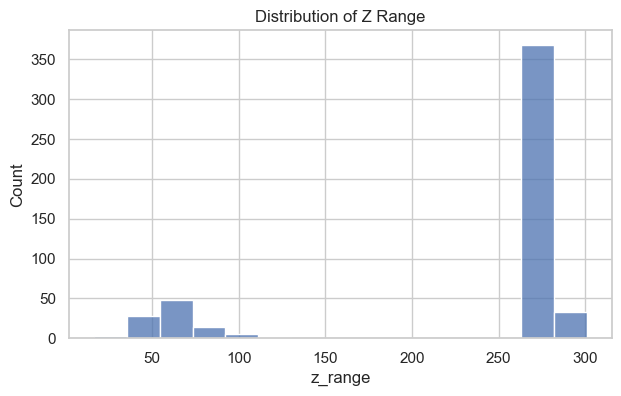

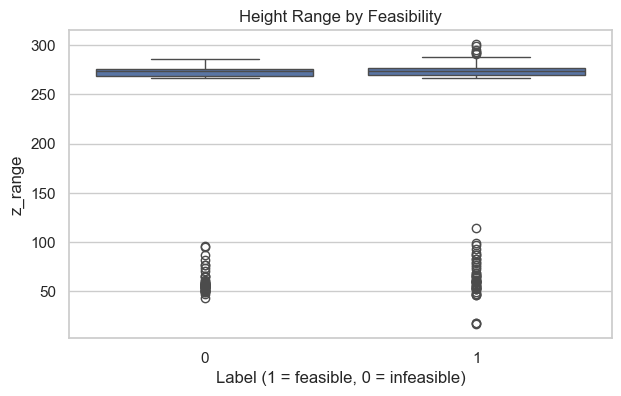

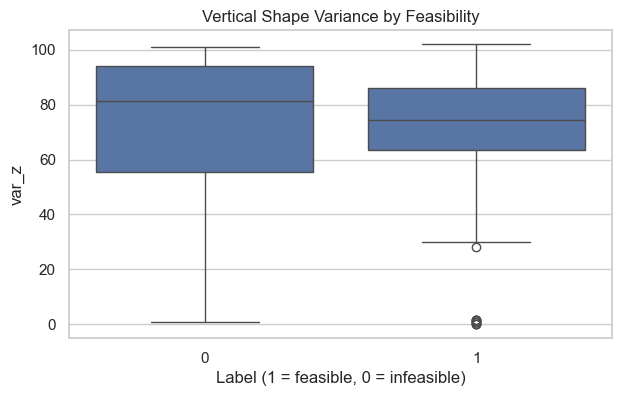

In [7]:
plt.figure(figsize=(7, 4))
sns.histplot(df["z_range"], bins=15)
plt.title("Distribution of Z Range")
plt.xlabel("z_range")
plt.show()

plt.figure(figsize=(7, 4))
sns.boxplot(x="label", y="z_range", data=df)
plt.title("Height Range by Feasibility")
plt.xlabel("Label (1 = feasible, 0 = infeasible)")
plt.show()

plt.figure(figsize=(7, 4))
sns.boxplot(x="label", y="var_z", data=df)
plt.title("Vertical Shape Variance by Feasibility")
plt.xlabel("Label (1 = feasible, 0 = infeasible)")
plt.show()


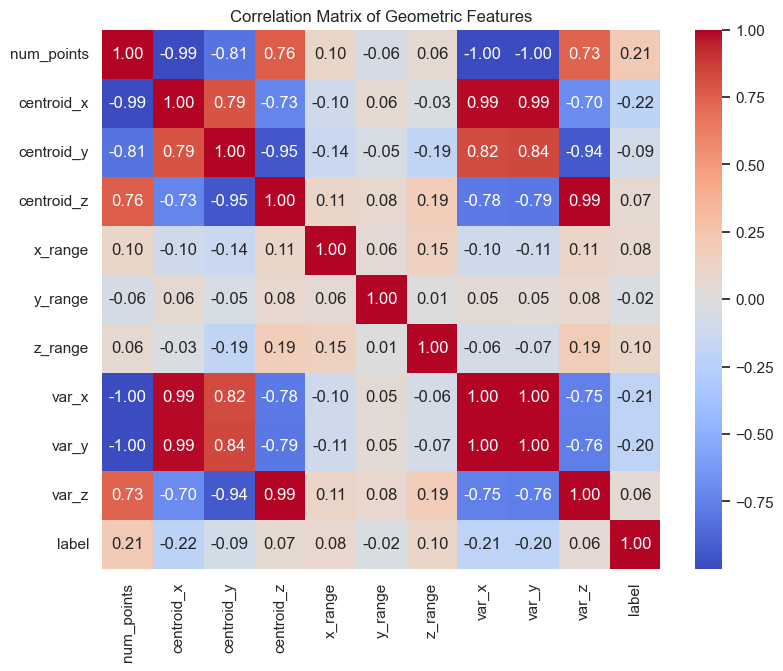

In [10]:
plt.figure(figsize=(9, 7))
sns.heatmap(df.drop(columns=["file"]).corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Geometric Features")
plt.show()


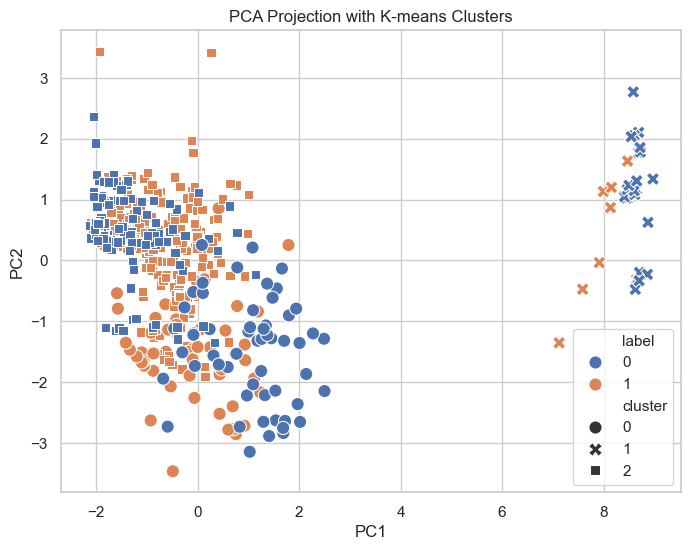

In [11]:
X_q1 = df.drop(columns=["label", "file"])
y_q1 = df["label"]

scaler_q1 = StandardScaler()
X_q1_scaled = scaler_q1.fit_transform(X_q1)

pca_q1 = PCA(n_components=2)
X_q1_pca = pca_q1.fit_transform(X_q1_scaled)

kmeans_q1 = KMeans(n_clusters=3, random_state=1, n_init=10)
clusters_q1 = kmeans_q1.fit_predict(X_q1_scaled)

pca_plot_df = pd.DataFrame({
    "PC1": X_q1_pca[:, 0],
    "PC2": X_q1_pca[:, 1],
    "label": y_q1,
    "cluster": clusters_q1
})

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=pca_plot_df,
    x="PC1",
    y="PC2",
    hue="label",
    style="cluster",
    s=90
)
plt.title("PCA Projection with K-means Clusters")
plt.show()


### Q1 Interpretation:

The point cloud data were summarized using the number of points, centroid coordinates, ranges, and variances along each axis. These summaries provide a privacy-preserving way to represent each part numerically while still capturing important geometric information.

From the exploratory plots, the number of sampled points appears relatively consistent across designs, which suggests the point clouds were collected with similar sampling density. The vertical geometry seems more informative than the horizontal geometry, especially through `z_range` and `var_z`. Infeasible parts tend to show more unusual vertical structure and more spread in these variables.

For inclusion in the analysis, I would keep points that represent the actual geometry of the object. I would exclude obvious noise points, isolated outliers, or scanning artifacts, because those can distort the extracted features. The PCA and clustering plot provides a lower-dimensional summary of the feature space and suggests that there is some structure in the data, although the two classes are not perfectly separated.


# Question 2  

At the data sourcing step, develop a strategy to select a smaller but more meaningful subset when samples arrive sequentially. Discuss how class imbalance affects performance, and show that sampling strategy can improve testing F1.



In [12]:
def sequential_sampling_demo(df, step=10, random_state=1):
    """
    Simulate sequential arrival of samples and track model F1 as sample size increases.
    """
    df_seq = df.sample(frac=1, random_state=random_state).reset_index(drop=True)
    results = []

    for n in range(max(20, step), len(df_seq) + 1, step):
        subset = df_seq.iloc[:n].copy()

        if subset["label"].nunique() < 2:
            continue

        X = subset.drop(columns=["label", "file"])
        y = subset["label"]

        try:
            X_train, X_test, y_train, y_test = train_test_split(
                X, y,
                test_size=0.30,
                stratify=y,
                random_state=1
            )

            model = Pipeline([
                ("scaler", StandardScaler()),
                ("model", LogisticRegression(max_iter=5000))
            ])

            model.fit(X_train, y_train)
            pred = model.predict(X_test)
            f1 = f1_score(y_test, pred)

            results.append({
                "n_samples": n,
                "f1": f1,
                "feasible_count": int((subset["label"] == 1).sum()),
                "infeasible_count": int((subset["label"] == 0).sum())
            })

        except Exception:
            pass

    return pd.DataFrame(results)


In [13]:
seq_results = sequential_sampling_demo(df, step=10)
display(seq_results)


,n_samples,f1,feasible_count,infeasible_count
0,20,0.500000,12,8
1,30,0.600000,17,13
2,40,0.666667,22,18
3,50,0.727273,25,25
4,60,0.600000,30,30
5,70,0.600000,34,36
6,80,0.642857,39,41
7,90,0.562500,45,45
8,100,0.580645,51,49
9,110,0.628571,57,53


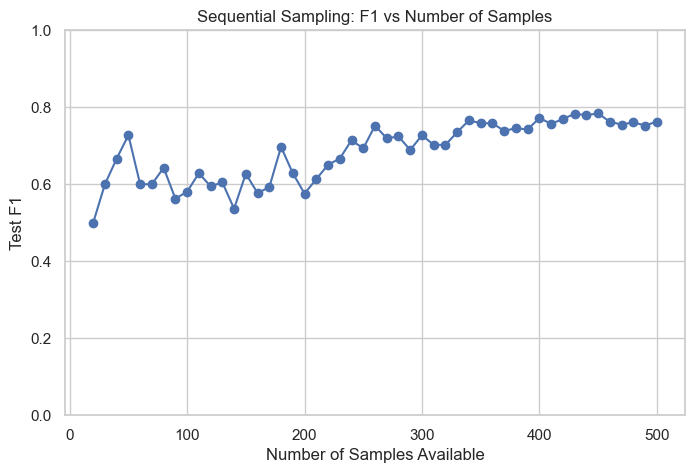

In [14]:
if not seq_results.empty:
    plt.figure(figsize=(8, 5))
    plt.plot(seq_results["n_samples"], seq_results["f1"], marker="o")
    plt.title("Sequential Sampling: F1 vs Number of Samples")
    plt.xlabel("Number of Samples Available")
    plt.ylabel("Test F1")
    plt.ylim(0, 1)
    plt.show()
else:
    print("Sequential sampling results were empty. This can happen if the dataset is very small.")


### Q2 Interpretation:

When samples arrive sequentially, I would not simply use the earliest available observations without checking class representation. Instead, I would try to preserve a meaningful balance between feasible and infeasible parts so that the training subset remains representative of the full problem.

Class imbalance matters because a model can appear to perform well overall while still doing a poor job on the minority class. For this reason, F1 score is a more useful metric than raw accuracy here because it accounts for both precision and recall. The sequential sampling results show how model performance may change as more samples become available, and they motivate choosing a smaller but more balanced subset rather than a convenient but biased one.


# Question 3  


Perform a literature review to identify more feature engineering methods for classification models. Discuss how unsupervised learning plays a role in feature engineering. Implement code to augment feature engineering in the model.




In [15]:
def augment_features(df):
    df_aug = df.copy()

    X = df_aug.drop(columns=["label", "file"])

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    pca = PCA(n_components=3)
    pca_features = pca.fit_transform(X_scaled)

    df_aug["pca1"] = pca_features[:, 0]
    df_aug["pca2"] = pca_features[:, 1]
    df_aug["pca3"] = pca_features[:, 2]

    kmeans = KMeans(n_clusters=3, random_state=1, n_init=10)
    clusters = kmeans.fit_predict(X_scaled)

    df_aug["cluster"] = clusters

    return df_aug


In [16]:
df_aug = augment_features(df)
display(df_aug.head())
print("\nColumns:")
print(df_aug.columns.tolist())


,num_points,centroid_x,centroid_y,centroid_z,x_range,y_range,z_range,var_x,var_y,var_z,label,file,pca1,pca2,pca3,cluster
0,270081,-11.293553,6.856237,-508.994764,185.807809,175.708568,54.123235,2963.377689,2650.751017,40.864570,1,3890.stl_pointcloud.ply,1.189816,-0.839690,1.775611,0
1,273460,-11.422041,6.711312,-508.057959,185.807809,175.662821,271.784954,2930.336228,2619.140380,72.909069,1,4138.stl_pointcloud.ply,-1.043947,-0.102096,-0.869864,2
2,272369,-11.381141,6.579553,-507.565124,185.807809,175.668206,276.894440,2937.981500,2624.174259,93.998765,1,900.stl_pointcloud.ply,-1.654525,0.502858,-0.456643,2
3,272729,-11.348682,6.650851,-507.731223,185.807809,175.664555,279.747935,2934.640913,2623.092829,85.698114,1,5336.stl_pointcloud.ply,-1.299850,0.296695,-0.697352,2
4,273673,-11.463161,6.685667,-508.901016,185.807809,175.638091,269.352572,2930.928543,2614.850521,39.223487,1,4135.stl_pointcloud.ply,-0.345047,-1.104362,-2.093302,2



Columns:
['num_points', 'centroid_x', 'centroid_y', 'centroid_z', 'x_range', 'y_range', 'z_range', 'var_x', 'var_y', 'var_z', 'label', 'file', 'pca1', 'pca2', 'pca3', 'cluster']


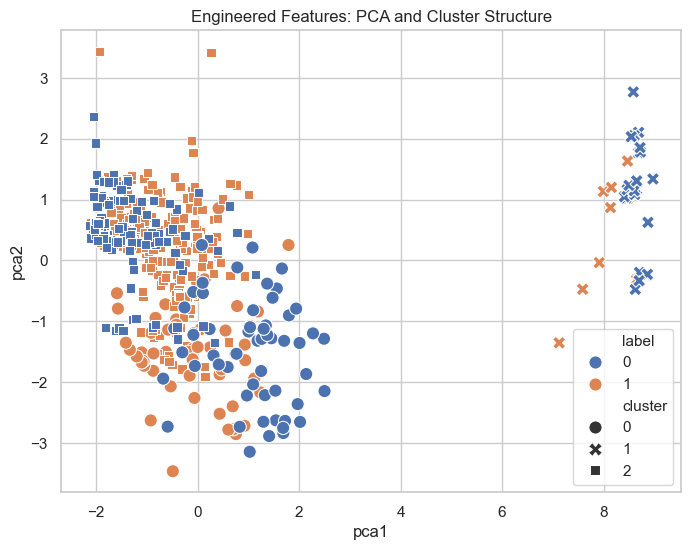

In [17]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=df_aug["pca1"],
    y=df_aug["pca2"],
    hue=df_aug["label"],
    style=df_aug["cluster"],
    s=90
)
plt.title("Engineered Features: PCA and Cluster Structure")
plt.show()


### Q3 Interpretation:

Feature engineering is important because the original point-cloud summaries may not fully describe the structure that separates feasible and infeasible parts. Unsupervised learning helps by discovering structure in the predictors without directly using the class labels.

Here, PCA creates low-dimensional components that capture major directions of variation in the geometric features. K-means adds a cluster-based feature that represents latent groups of parts with similar structure. These engineered features may improve downstream classification because manufacturing feasibility is likely determined by combinations of geometric characteristics rather than by one single raw variable alone.


# Question 4  

Design a more comprehensive computation pipeline system. Implement multiple pipelines and compare F1 scores. Also perform diagnosis of misclassified samples.

 

In [18]:
def run_pipelines(X_train, X_test, y_train, y_test):
    pipelines = {
        "LogisticRegression": Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=5000))
        ]),
        "RandomForest": RandomForestClassifier(n_estimators=300, random_state=1),
        "GradientBoosting": GradientBoostingClassifier(random_state=1),
        "ExtraTrees": ExtraTreesClassifier(n_estimators=300, random_state=1),
        "DecisionTree": DecisionTreeClassifier(random_state=1),
        "SVM": Pipeline([
            ("scaler", StandardScaler()),
            ("model", SVC())
        ]),
        "KNN": Pipeline([
            ("scaler", StandardScaler()),
            ("model", KNeighborsClassifier())
        ]),
        "MLP": Pipeline([
            ("scaler", StandardScaler()),
            ("model", MLPClassifier(max_iter=2000, random_state=1))
        ])
    }

    results = []
    fitted_models = {}

    best_model = None
    best_name = None
    best_f1 = -1

    for name, model in pipelines.items():
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        f1 = f1_score(y_test, pred)

        results.append({
            "Pipeline": name,
            "F1 Score": f1
        })

        fitted_models[name] = model

        if f1 > best_f1:
            best_f1 = f1
            best_model = model
            best_name = name

    results_df = pd.DataFrame(results).sort_values("F1 Score", ascending=False)
    return results_df, best_model, best_name, fitted_models


In [19]:
X = df_aug.drop(columns=["label", "file"])
y = df_aug["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=1
)

results_df, best_model, best_name, fitted_models = run_pipelines(X_train, X_test, y_train, y_test)
display(results_df)


,Pipeline,F1 Score
3,ExtraTrees,0.838710
1,RandomForest,0.821622
2,GradientBoosting,0.793478
5,SVM,0.786885
7,MLP,0.766667
6,KNN,0.755556
0,LogisticRegression,0.708134
4,DecisionTree,0.704545


In [20]:
best_pred = best_model.predict(X_test)

print("Best pipeline:", best_name)
print("Best F1 score:", f1_score(y_test, best_pred))
print()
print(classification_report(y_test, best_pred))


Best pipeline: ExtraTrees
Best F1 score: 0.8387096774193549

              precision    recall  f1-score   support

           0       0.78      0.70      0.74        60
           1       0.81      0.87      0.84        90

    accuracy                           0.80       150
   macro avg       0.80      0.78      0.79       150
weighted avg       0.80      0.80      0.80       150



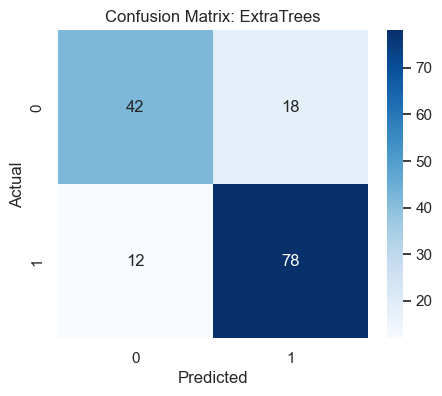

In [21]:
cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix: {best_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [22]:
test_results = X_test.copy()
test_results["actual"] = y_test.values
test_results["predicted"] = best_pred

misclassified_idx = test_results.index[test_results["actual"] != test_results["predicted"]]

misclassified_files = df_aug.loc[misclassified_idx, ["file", "label"]].copy()
misclassified_files["predicted"] = test_results.loc[misclassified_idx, "predicted"].values

display(misclassified_files)


,file,label,predicted
469,2390.stl_pointcloud.ply,0,1
169,5301.stl_pointcloud.ply,1,0
308,4128.stl_pointcloud.ply,0,1
457,3367.stl_pointcloud.ply,0,1
285,834.stl_pointcloud.ply,1,0
433,4908.stl_pointcloud.ply,0,1
158,840.stl_pointcloud.ply,1,0
371,2844.stl_pointcloud.ply,0,1
357,2193.stl_pointcloud.ply,0,1
24,776.stl_pointcloud.ply,1,0


### Q4 Interpretation:

I compared several classification pipelines and selected the best model using test-set F1 score. This approach is useful because it avoids assuming that one classifier is best in advance and instead lets the data determine which pipeline performs most effectively.

The confusion matrix shows the number of correct and incorrect classifications, and the misclassified sample table helps identify borderline or unusual parts. These misclassified cases are important because they may indicate where the current feature set does not fully capture the geometry needed to separate feasible and infeasible designs.


### Overall Summary

Across Questions 1–4, I developed a workflow for reading point clouds, extracting geometric features, exploring the data visually, augmenting the features with unsupervised learning, and comparing multiple classification pipelines.

The exploratory analysis suggests that vertical geometric measures such as `z_range` and `var_z` may be especially informative. The sequential sampling section shows why class balance matters when selecting a smaller subset from arriving samples. Feature engineering through PCA and K-means adds structure to the dataset, and the pipeline comparison step identifies the strongest predictive model using F1 score.

Overall, the results support the idea that manufacturing feasibility is influenced by a combination of geometric characteristics rather than by one single variable alone.
